# Find intersection between Cone of influence and Instantaneous frequency

In [3]:
%load_ext autoreload
%autoreload 2

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sys import path
path.append('../wavelet/')
path.append('../signals/')

import wavelet_funcs as wf
from signals import cosine_with_arctan_freq


In [31]:
t, freq_func, s = cosine_with_arctan_freq(20, 100, 2, 0.3, 3)

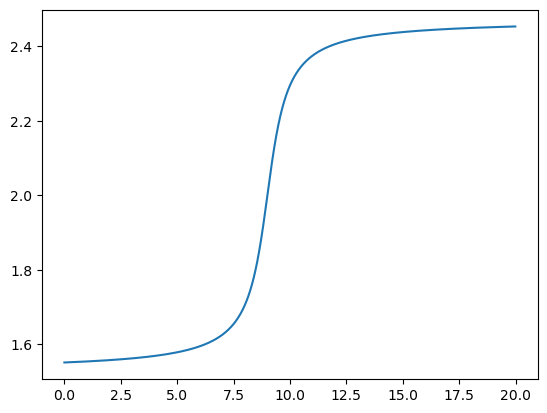

In [33]:
plt.plot(t, freq_func)

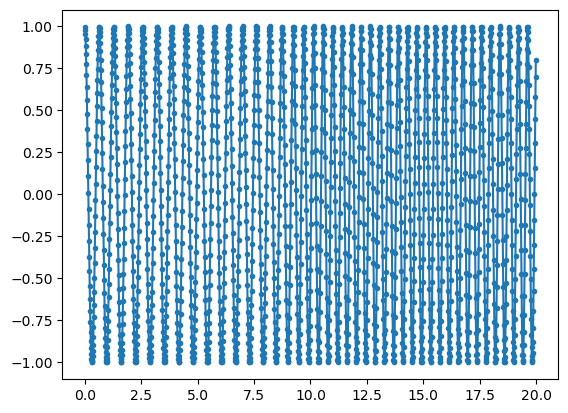

In [35]:
plt.plot(t, s, marker='.')

(-0.005, 19.995000000000005)

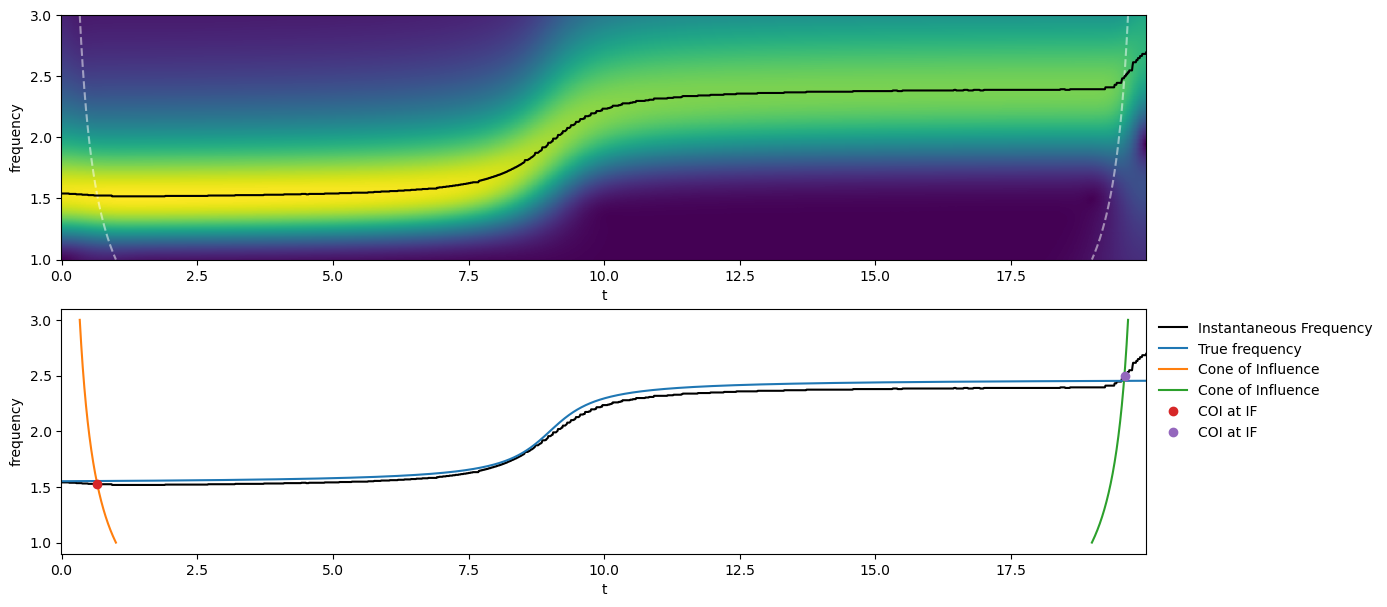

In [41]:
bw = 1,
cf = 1

res = wf.cwt_with_coi(s,t,1,3,bandwidth=bw, central_freq=cf,method='fft', padding_fraction=0.5, nscales=512, precision=18, pad_mode='reflect')
rdg = wf.wavelet_ridge(res.wt_coefs, res.f, res.t)
coi_left = wf.intersection_between_coi_and_if_cmor(res.coi, rdg.frequency, res.t, bw, cf)
coi_right = wf.intersection_between_coi_and_if_cmor(res.coi, rdg.frequency, res.t, bw, cf, at_the_end=True)

f, (ax,ax1) = plt.subplots(2,1,figsize=(14,7),)
wf.plot_cwt(abs(res.wt_coefs), res.f, res.t, coi=res.coi, ax=ax);
rdg.frequency.plot(ax=ax, color='k')

rdg.frequency.plot(ax=ax1, color='k', label='Instantaneous Frequency')
ax1.plot(t, freq_func, label='True frequency')
ax1.plot(res.coi, res.f,
         res.t.max()-res.coi, res.f,
         label='Cone of Influence'
        )
ax1.plot(*coi_left, marker='o',  ls='', label='COI at IF')
ax1.plot(*coi_right, marker='o', ls='', label='COI at IF')
ax1.legend(bbox_to_anchor=(1,1), frameon=False)
ax1.set_xlim(ax.get_xlim())

Text(0.5, 1.0, 'True - Estimated frequency')

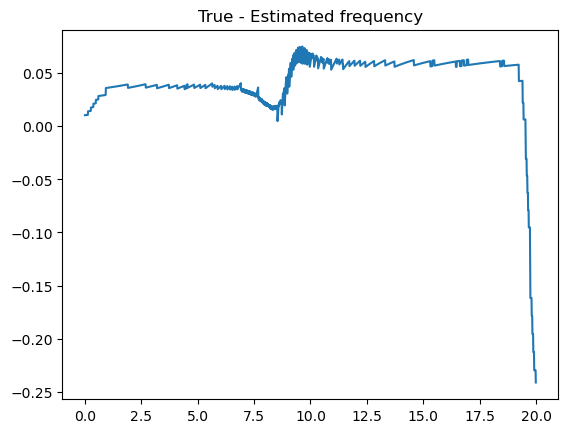

In [43]:
plt.plot(t, freq_func - rdg.frequency)
plt.title('True - Estimated frequency')